# Autonomous Systems Portfolio 1  

|Name     |Studentnumber|Github    |
|---------|-------------|----------|
|Henry Lau|22122958     |HenryLau08|
|Michal|||
|Mohamed|22143572|mobelaachir|

Game: Connect 4

In [3]:
pip install pettingzoo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Strategie Geef Niet Op

De “Strategie Geef Niet Op” is een slimme, verdedigende manier om Vier op een Rij te spelen.
Je speelt rustig en geeft niet op, ook niet als het moeilijk wordt. In plaats van snel aan te vallen, bouw je eerst een sterke en veilige verdediging. Je neemt weinig risico en zorgt dat je tegenstander steeds minder keuzes heeft.
Met kleine, slimme zetten dwing je de tegenstander tot fouten. Daarna kies je het juiste moment om toe te slaan en te winnen.



1. Win of blokkeer meteen:

        - Kun je direct winnen? Doe dat meteen.
        - Kan je tegenstander winnen? Blokkeer dat direct. 
2. Maak geen zwakke plekken:

        - Doe geen zet die je tegenstander laat winnen in de volgende beurt.
        - Denk dus altijd één stap vooruit.
3. Bouw een sterke basis:

        - Speel vooral onderaan en in het midden van het bord.
4. Wees geduldig:

        - Val niet zomaar aan. Wacht op fouten van je tegenstander.
5. Beperk de keuzes van de tegenstander: 

        - Minder opties geven aan de tegenstander.
        - Zorg dat je de controle over het spel hebt.


Met de “Strategie Geef Niet Op” speel je rustig, slim en geduldig.
Je maakt weinig fouten en wacht op het juiste moment om te winnen.



# Belangrijke onderdelen
Dit deel van de code laadt de gereedschappen die we nodig hebben om het spel te maken. Het kiest ook de kleuren en de grootte van het speelbord.
- numpy helpt ons met getallen en tabellen (het speelbord).
- matplotlib.pyplot en matplotlib.patches helpen ons om plaatjes (het speelbord) te tekenen.
- IPython.display helpt om het scherm schoon te maken en nieuwe plaatjes te laten zien.
- time laat het programma even wachten, zodat het niet te snel gaat.
- %matplotlib inline zorgt ervoor dat de plaatjes direct in je notitieboekje (zoals Jupyter) te zien zijn.

Daarnaast stellen we de kleuren in voor het bord, de tekst, de spelers (jij en de computer) en de lege vakjes. Ook zeggen we hoe breed en hoog het bord is.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output, display
import time

# Zorgt voor directe weergave in notebooks
%matplotlib inline

# Colors
BOARD_COLOR = '#323E50'    # Het donkerblauw/grijs van de achtergrond
TEXT_COLOR = '#FFFFFF'     # Wit voor tekst
ACCENT_COLOR = '#4BC3E0'   # Het lichtblauwe van het kader
PLAYER_COLOR = '#FFFFFF'   # Wit voor de speler (Jij)
AI_COLOR = '#4BC3E0'       # Lichtblauw voor de AI (Speler 2)
EMPTY_COLOR = '#2A3444'    # Donkerder blauw voor lege plekken

BOARD_WIDTH = 7
BOARD_HEIGHT = 6


## Handige functies voor het spel
Deze functies zijn kleine programmaatjes die het spel helpen werken. Ze doen dingen zoals het bord klaarmaken, een schijfje laten vallen en kijken of iemand heeft gewonnen.
- convert_observation(obs): Dit maakt van de informatie die het spel geeft een bord dat wij makkelijk kunnen gebruiken. Het verandert de informatie over de schijfjes van de spelers in nummers (1 voor jou, 2 voor de computer).
- print_text_board(board, mask): Deze functie laat het bord zien als tekst in de computer. Zo kun je zien waar de schijfjes liggen met X (jij), O (computer) en . (leeg).
- drop_piece(board, col, player): Deze functie probeert een schijfje van een speler in een bepaalde kolom te laten vallen. Het zoekt de laagste lege plek in die kolom en legt daar het schijfje neer. Als de kolom vol is, gebeurt er niets.
- check_win(board, player): Deze functie kijkt of een speler heeft gewonnen. Het controleert alle rijen, kolommen en schuine lijnen om te zien of er vier schijfjes van dezelfde speler op een rij liggen.

In [ ]:
def convert_observation(obs, agent):
    """
    Convert PettingZoo observation to absolute board:
    1 = player_0
    2 = player_1
    """
    board = np.zeros((6, 7), dtype=int)

    # channel 0 = current agent
    # channel 1 = opponent
    if agent == "player_0":
        me = 1
        opp = 2
    else:
        me = 2
        opp = 1

    for i in range(6):
        for j in range(7):
            if obs[i, j, 0] == 1:
                board[i, j] = me
            elif obs[i, j, 1] == 1:
                board[i, j] = opp

    return board

def print_text_board(board, mask):
    """De tekstuele weergave onder het bord"""
    print("\nCurrent board:")
    for i in range(6):
        row = []
        for j in range(7):
            if board[i, j] == 1: row.append("X")
            elif board[i, j] == 2: row.append("O")
            else: row.append(".")
        print(" ".join(row))
    print("\nColumns: " + " ".join([str(i) if mask[i] else "x" for i in range(7)]))

def drop_piece(board, col, player):
    new_board = board.copy()
    for row in range(5, -1, -1):
        if new_board[row, col] == 0:
            new_board[row, col] = player
            return new_board
    return None

def check_win(board, player):
    rows, cols = board.shape
    for r in range(rows):
        for c in range(cols - 3):
            if all(board[r, c + i] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols):
            if all(board[r + i, c] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(board[r + i, c + i] == player for i in range(4)): return True
    for r in range(3, rows):
        for c in range(cols - 3):
            if all(board[r - i, c + i] == player for i in range(4)): return True
    return False


## Het speelbord tekenen
Deze functies zorgen ervoor dat het speelbord er mooi uitziet op het scherm. Ze gebruiken de kleuren en groottes die we eerder hebben gekozen.
- draw_game_board(ax, board): Deze functie tekent het bord zelf. Het maakt een rechthoek voor het bord en tekent dan cirkels voor alle vakjes. De kleur van de cirkel hangt af van wie zijn schijfje daar ligt (jij, computer of leeg). Ook worden de kolomnummers onderaan het bord gezet.
- create_game_ui(board, current_player, game_status=""): Deze functie maakt de hele afbeelding van het spel. Het gebruikt draw_game_board om het bord te tekenen, voegt een titel toe, laat zien wiens beurt het is en toont eventuele berichten over de status van het spel (bijvoorbeeld als iemand heeft gewonnen).

In [13]:
def draw_game_board(ax, board):
    """Teken het bord met ADS & AI design en kolomnummers"""
    ax.set_xlim(-0.5, BOARD_WIDTH - 0.5)
    ax.set_ylim(-0.5, BOARD_HEIGHT + 0.5) # Ruimte voor nummers aan de onderkant
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    
    # Teken het bord achtergrond
    board_rect = patches.Rectangle((-0.5, -0.5), BOARD_WIDTH, BOARD_HEIGHT, 
                                    linewidth=4, edgecolor=ACCENT_COLOR, facecolor=BOARD_COLOR)
    ax.add_patch(board_rect)
    
    # Teken cellen en schijven
    for row in range(BOARD_HEIGHT):
        for col in range(BOARD_WIDTH):
            # Schijven
            if board[row, col] == 1:  # Speler (Wit)
                circle = patches.Circle((col, row), 0.38, color=PLAYER_COLOR, ec='#CCCCCC', linewidth=2)
                ax.add_patch(circle)
            elif board[row, col] == 2:  # AI (Lichtblauw)
                circle = patches.Circle((col, row), 0.38, color=AI_COLOR, ec='#3A9AB3', linewidth=2)
                ax.add_patch(circle)
            else:  # Leeg
                circle = patches.Circle((col, row), 0.38, color=EMPTY_COLOR, ec='#1A2434', linewidth=1)
                ax.add_patch(circle)
                
    # VOEG KOLOMNUMMERS TOE AAN DE ONDERKANT
    for col in range(BOARD_WIDTH):
        ax.text(col, BOARD_HEIGHT, str(col), ha='center', va='top', 
                fontsize=14, fontweight='bold', color=ACCENT_COLOR)

def create_game_ui(board, current_player, game_status=""):
    """Creëer de volledige ADS & AI UI"""
    fig = plt.figure(figsize=(10, 8), facecolor=BOARD_COLOR)
    
    # Hoofd bord
    ax_board = plt.subplot(111)
    draw_game_board(ax_board, board)
    
    # Titel met ADS & AI kleuren
    title_text = "ADS & AI - VIER OP EEN RIJ"
    fig.suptitle(title_text, fontsize=24, fontweight='bold', color=ACCENT_COLOR, y=0.98)
    
    # Status bar
    player_info = f"Beurt: {'Jij (Wit - X)' if current_player == 1 else 'Computer (Blauw - O)'}"
    fig.text(0.5, 0.90, player_info, ha='center', fontsize=14, 
             color=TEXT_COLOR, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=BOARD_COLOR, edgecolor=ACCENT_COLOR, linewidth=2))
    
    if game_status:
        fig.text(0.5, 0.05, game_status, ha='center', fontsize=14, 
                 color=ACCENT_COLOR, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor=BOARD_COLOR, edgecolor=TEXT_COLOR, linewidth=2))
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    return fig


## De strategie van de computer (AI)
Deze functie bepaalt hoe de computer speelt. De computer probeert slimme zetten te doen om te winnen of om jou te blokkeren.
- strategy_player_2(board, mask): Dit is de hersenen van de computer. De computer kijkt eerst of hij zelf kan winnen, of dat hij jou kan blokkeren zodat jij niet wint. Als dat niet kan, zoekt hij naar "veilige" zetten. Een veilige zet is een zet waarbij jij niet direct daarna kunt winnen. Als er meerdere veilige zetten zijn, kiest de computer het liefst een kolom in het midden van het bord, omdat dat vaak de beste plek is. Als er geen veilige zetten zijn, kiest de computer gewoon een willekeurige lege kolom.

Geef Niet Op strategie, die in de functie strategy_player_2 zit, is een slimme manier voor de computer om Vier op een Rij te spelen. De computer denkt in stappen:
1. Direct winnen of blokkeren: De computer kijkt eerst of hij in de volgende zet zelf kan winnen. Als dat zo is, doet hij die zet. Als hij niet zelf kan winnen, kijkt hij of jij in de volgende zet kunt winnen. Als dat zo is, blokkeert hij jou door zijn schijfje daar neer te leggen.
2. Veilige zetten zoeken: Als de computer niet direct kan winnen of jou kan blokkeren, zoekt hij naar "veilige" zetten. Een veilige zet is een zet waarbij jij niet direct daarna kunt winnen. De computer wil niet dat jij een makkelijke winst krijgt.
3. Midden van het bord is belangrijk: Als er meerdere veilige zetten zijn, kiest de computer het liefst een kolom in het midden van het bord (kolom 3, dan 2, dan 4, enzovoort). Dit is vaak een goede plek om te spelen, omdat je vanuit het midden makkelijker rijen van vier kunt maken.
4. Willekeurige zet (als niets anders kan): Als er geen slimme of veilige zetten zijn, kiest de computer gewoon een willekeurige lege kolom. Dit gebeurt alleen als er echt geen betere optie is.

Kortom, de computer probeert altijd eerst te winnen of jou te stoppen, dan veilig te spelen, en kiest het liefst het midden van het bord.

In [14]:
def strategy_player_2(board, mask):
    player = 2
    opponent = 1
    valid_moves = np.where(mask)[0]
    
    # STAP 1: Kan de computer DIRECT winnen? (Altijd de hoogste prioriteit)
    for col in valid_moves:
        temp = drop_piece(board, col, player)
        if temp is not None and check_win(temp, player):
            return int(col)

    # STAP 2: Moet de computer de tegenstander blokkeren?
    for col in valid_moves:
        temp = drop_piece(board, col, opponent)
        if temp is not None and check_win(temp, opponent):
            return int(col)

    # STAP 3: Veilige zetten (voorkom dat de tegenstander wint na jouw zet)
    safe_moves = []
    for col in valid_moves:
        temp_board = drop_piece(board, col, player)
        # Maak een tijdelijk masker voor de volgende beurt
        next_mask = [1 if temp_board[0, c] == 0 else 0 for c in range(7)]
        
        # Check of de tegenstander kan winnen direct na deze zet
        can_opp_win = False
        for c in range(7):
            if next_mask[c]:
                test_opp_board = drop_piece(temp_board, c, opponent)
                if test_opp_board is not None and check_win(test_opp_board, opponent):
                    can_opp_win = True
                    break
        
        if not can_opp_win:
            safe_moves.append(col)
    
    # STAP 4: Kies een zet uit de veilige zetten, met voorkeur voor het midden
    use_cols = safe_moves if safe_moves else valid_moves
    center_priority = [3, 2, 4, 1, 5, 0, 6]
    
    for col in center_priority:
        if col in use_cols:
            return int(col)
            
    # STAP 5: Als er echt niets anders is, kies een willekeurige zet
    return int(np.random.choice(valid_moves))


In [ ]:

def smart_strategy(board, mask):
    """
    Verbeterde Rule-based AI strategie voor Vier op een Rij.
    
    Prioriteit:
    1. Win
    2. Block win
    3. Block fork
    4. Fork
    5. Center (kolom 3)
    6. Random
    """
    # De AI is in jouw code altijd player_1 (als agent == "player_1", wat overeenkomt met waarde 2 op het bord)
    # We gaan ervan uit dat de computer speler 2 is (O) en jij speler 1 (X)
    player = 2 
    opponent = 1
    valid_moves = np.where(mask)[0]

    # --- HULPFUNCTIES VOOR DE LOGICA ---
    
    def drop_piece_temp(temp_board, col, p):
        """Simuleert een zet op een tijdelijk bord."""
        new_board = temp_board.copy()
        for row in range(5, -1, -1):
            if new_board[row, col] == 0:
                new_board[row, col] = p
                return new_board
        return None

    def check_win_temp(temp_board, p):
        """Kijkt of speler 'p' heeft gewonnen op het tijdelijke bord."""
        # Horizontaal
        for r in range(6):
            for c in range(4):
                if all(temp_board[r, c+i] == p for i in range(4)): return True
        # Verticaal
        for r in range(3):
            for c in range(7):
                if all(temp_board[r+i, c] == p for i in range(4)): return True
        # Diagonaal
        for r in range(3):
            for c in range(4):
                if all(temp_board[r+i, c+i] == p for i in range(4)): return True
            for c in range(3, 7):
                if all(temp_board[r+i, c-i] == p for i in range(4)): return True
        return False

    def count_winning_threats(temp_board, p):
        """Telt op hoeveel manieren speler 'p' kan winnen in de volgende beurt."""
        threats = 0
        for col in range(7):
            if temp_board[0, col] == 0: # Als de kolom niet vol is
                test_board = drop_piece_temp(temp_board, col, p)
                if test_board is not None and check_win_temp(test_board, p):
                    threats += 1
        return threats

    # --- DE STRATEGIE STAP VOOR STAP ---

    # 1. Win: Kan de computer nu direct winnen?
    for col in valid_moves:
        temp = drop_piece_temp(board, col, player)
        if temp is not None and check_win_temp(temp, player):
            return int(col)

    # 2. Block win: Kan jij nu winnen? De computer blokkeert je!
    for col in valid_moves:
        temp = drop_piece_temp(board, col, opponent)
        if temp is not None and check_win_temp(temp, opponent):
            return int(col)

    # 3. Block fork: Voorkom dat jij een 'vork' maakt (2 win-kansen tegelijk)
    for col in valid_moves:
        temp = drop_piece_temp(board, col, opponent)
        if temp is not None and count_winning_threats(temp, opponent) >= 2:
            return int(col)

    # 4. Fork: De computer probeert zelf een 'vork' te maken
    for col in valid_moves:
        temp = drop_piece_temp(board, col, player)
        if temp is not None and count_winning_threats(temp, player) >= 2:
            return int(col)

    # 5. Center: Is de middelste kolom (3) nog vrij?
    if 3 in valid_moves:
        return 3

    # 6. Random: Doe een willekeurige zet uit de beschikbare kolommen
    return int(np.random.choice(valid_moves))


In [ ]:
def defensive_strategy(board, mask):
    """
    Defensieve strategie die werkt met board en mask.
    In jouw code is player_0 altijd 1 en player_1 altijd 2.
    """
    valid_cols = [int(c) for c in np.where(mask)[0]]
    if not valid_cols:
        return 0

    # Omdat we in de 'if agent == "player_0"' blok zitten, 
    # weten we dat de huidige speler player_0 is (waarde 1).
    player = 1 
    opp = 2

    # --- INTERNE HULPFUNCTIES ---
    def get_drop_row(temp_board, col):
        for r in range(5, -1, -1):
            if temp_board[r, col] == 0:
                return r
        return None

    def count_winning_moves(temp_board, p):
        count = 0
        for c in range(7):
            row = get_drop_row(temp_board, c)
            if row is not None:
                sim = temp_board.copy()
                sim[row, c] = p
                if check_win(sim, p):
                    count += 1
        return count

    def gives_free_win_above(col):
        row = get_drop_row(board, col)
        if row is None or row == 0:
            return False
        sim = board.copy()
        sim[row, col] = player
        test = sim.copy()
        test[row - 1, col] = opp
        return check_win(test, opp)

    def future_opp_wins(col):
        row = get_drop_row(board, col)
        if row is None: return 999
        sim = board.copy()
        sim[row, col] = player
        return count_winning_moves(sim, opp)

    def future_my_forks(col):
        row = get_drop_row(board, col)
        if row is None: return 0
        sim = board.copy()
        sim[row, col] = player
        count = 0
        for c in range(7):
            r2 = get_drop_row(sim, c)
            if r2 is not None:
                sim2 = sim.copy()
                sim2[r2, c] = player
                if count_winning_moves(sim2, player) >= 2:
                    count += 1
        return count

    def find_fork_cols(p):
        fork_cols = []
        for col in valid_cols:
            row = get_drop_row(board, col)
            if row is not None:
                sim = board.copy()
                sim[row, col] = p
                if count_winning_moves(sim, p) >= 2:
                    fork_cols.append(col)
        return fork_cols

    # --- DE STRATEGIE LOGICA ---

    # 1. Win
    for col in valid_cols:
        row = get_drop_row(board, col)
        if row is not None:
            sim = board.copy()
            sim[row, col] = player
            if check_win(sim, player):
                return col

    # 2. Blok win
    for col in valid_cols:
        row = get_drop_row(board, col)
        if row is not None:
            sim = board.copy()
            sim[row, col] = opp
            if check_win(sim, opp):
                return col

    # 3. Fork (Zelf een vork maken)
    my_forks = find_fork_cols(player)
    if my_forks:
        safe = [c for c in my_forks if not gives_free_win_above(c)]
        pool = safe if safe else my_forks
        return min(pool, key=future_opp_wins)

    # 4. Naar fork bouwen
    safe_cols = [c for c in valid_cols if not gives_free_win_above(c)]
    build_pool = safe_cols if safe_cols else valid_cols
    # Zoek de beste kolom om een vork op te bouwen
    best_build = max(build_pool, key=future_my_forks)
    if future_my_forks(best_build) > 0:
        return best_build

    # 5. Blokkeer fork van tegenstander
    opp_forks = find_fork_cols(opp)
    if opp_forks:
        safe_cols = [c for c in valid_cols if not gives_free_win_above(c)]
        pool = safe_cols if safe_cols else valid_cols
        return min(pool, key=future_opp_wins)

    # 6. Midden en overige kolommen (Veiligheid eerst)
    safe_cols = [c for c in valid_cols if not gives_free_win_above(c)]
    pool = safe_cols if safe_cols else valid_cols

    if 3 in pool:
        return 3

    for col in [2, 4, 1, 5, 0, 6]:
        if col in pool:
            return col

    return pool[0]


- Win: De computer kijkt eerst of hij de vierde schijf in een rij kan leggen om direct te winnen.
- Block: Als de computer niet kan winnen, kijkt hij of jij drie op een rij hebt. Hij blokkeert je dan meteen.
- Block Fork: De computer kijkt of jij een slimme zet kunt doen waardoor je in de volgende beurt op twee manieren kunt winnen. Hij probeert dit te voorkomen.
- Fork: De computer probeert zelf een situatie te maken waarin hij twee win-kansen tegelijk heeft.
- Prioriteit: Als er geen slimme zetten zijn, kiest de computer voor het midden (kolom 3). Dat is de beste plek. Daarna kijkt hij naar de kolommen die het dichtst bij het midden liggen (2 en 4).

In [ ]:
def custom_priority_strategy(board, mask):
    """
    AI Strategie op basis van jouw specifieke structuur:
    1. Win (Direct winnen)
    2. Block (Tegenstander blokkeren)
    3. Block Fork (Voorkomen dat tegenstander een vork maakt)
    4. Fork (Zelf een vork maken)
    5. Random (Willekeurige kolom tussen 1 en 5 die nog vrij is)
    """
    # In jouw code is player_0 = 1 en player_1 = 2
    player = 1 
    opp = 2
    
    valid_moves = np.where(mask)[0]
    
    if len(valid_moves) == 0:
        return 0

    # --- HULPFUNCTIES ---
    def get_drop_row(temp_board, col):
        for r in range(5, -1, -1):
            if temp_board[r, col] == 0:
                return r
        return None

    def count_winning_moves(temp_board, p):
        count = 0
        for c in range(7):
            row = get_drop_row(temp_board, c)
            if row is not None:
                sim = temp_board.copy()
                sim[row, c] = p
                if check_win(sim, p):
                    count += 1
        return count

    # --- DE STRATEGIE VOLGORDE ---

    # 1. Win: Kan ik nu direct winnen? (Over het hele bord 0-6)
    for col in valid_moves:
        row = get_drop_row(board, col)
        if row is not None:
            sim = board.copy()
            sim[row, col] = player
            if check_win(sim, player):
                return int(col)

    # 2. Block: Kan de tegenstander nu winnen? Blokkeer het! (Over het hele bord 0-6)
    for col in valid_moves:
        row = get_drop_row(board, col)
        if row is not None:
            sim = board.copy()
            sim[row, col] = opp
            if check_win(sim, opp):
                return int(col)

    # 3. Block Fork: Voorkom dat de tegenstander een vork maakt
    for col in valid_moves:
        row = get_drop_row(board, col)
        if row is not None:
            sim = board.copy()
            sim[row, col] = opp
            if count_winning_moves(sim, opp) >= 2:
                return int(col)

    # 4. Fork: Maak zelf een vork
    for col in valid_moves:
        row = get_drop_row(board, col)
        if row is not None:
            sim = board.copy()
            sim[row, col] = player
            if count_winning_moves(sim, player) >= 2:
                return int(col)

    # 5. Random tussen 1 en 5:
    # We kijken welke kolommen van 1 t/m 5 nog vrij zijn
    inner_valid_moves = [c for c in valid_moves if 1 <= c <= 5]
    
    if inner_valid_moves:
        # Kies een willekeurige kolom uit 1, 2, 3, 4 of 5
        return int(np.random.choice(inner_valid_moves))
    else:
        # Als 1 t/m 5 allemaal vol zijn, kies dan pas uit 0 of 6
        return int(np.random.choice(valid_moves))



## Het spel spelen (de hoofdloop)
Dit is het deel waar het spel echt wordt gespeeld. Het zorgt ervoor dat jij en de computer om de beurt een zet doen, en dat het bord steeds opnieuw wordt getekend.
- from pettingzoo.classic import connect_four_v3: Dit laadt het spel "Vier op een Rij" van een speciale bibliotheek (pettingzoo).
- env = connect_four_v3.env(render_mode="rgb_array"): Dit start het spel. render_mode="rgb_array" betekent dat we het bord als een plaatje willen zien.
- env.reset(seed=42): Dit start een nieuw spel. seed=42 zorgt ervoor dat het spel elke keer op dezelfde manier begint, wat handig is om te testen.
- De for agent in env.agent_iter(): lus zorgt ervoor dat jij en de computer om de beurt aan de beurt komen.
- Binnen de lus wordt het bord getekend, wordt gekeken of het spel is afgelopen (winst, verlies of gelijkspel) en wordt er gevraagd om jouw zet of de computer doet een zet met zijn strategie.
- env.step(action): Dit voert de gekozen zet uit in het spel.
- Aan het einde wordt het spel afgesloten en krijg je een bedankje.

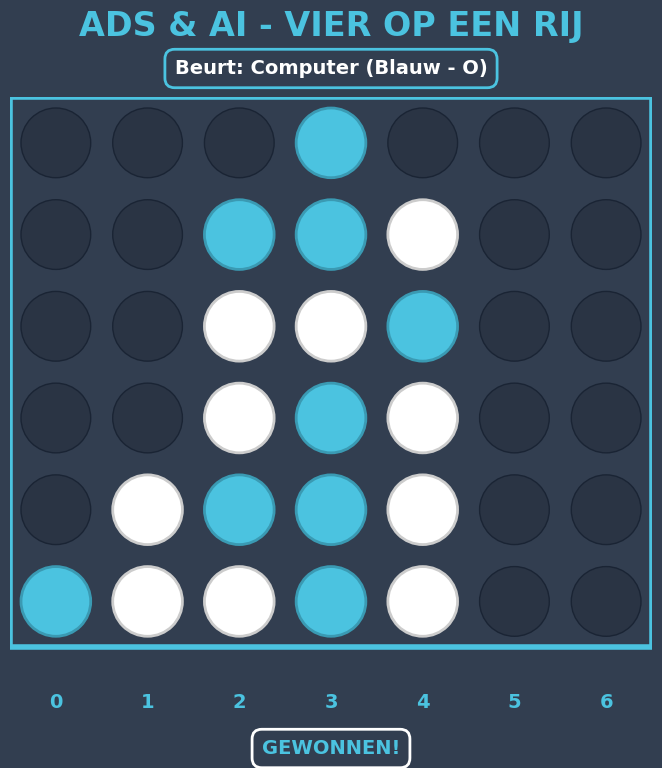


Current board:
. . . O . . .
. . O O X . .
. . X X O . .
. . X O X . .
. X O O X . .
O X X O X . .

Columns: 0 1 2 x 4 5 6


In [39]:
from pettingzoo.classic import connect_four_v3

env = connect_four_v3.env(render_mode="rgb_array")
env.reset(seed=42)

for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()
    board = convert_observation(raw_observation["observation"], agent)
    mask = raw_observation["action_mask"]
    
    # UI Update
    clear_output(wait=True)
    current_player = 1 if agent == "player_0" else 2
    
    if termination or truncation:
        if reward == 1:
            status = "GEWONNEN!" if agent == "player_0" else "ADS & AI WINT!"
        elif reward == -1:
            status = "ADS & AI WINT!" if agent == "player_0" else "GEWONNEN!"
        else:
            status = "GELIJKSPEL!"
            
        fig = create_game_ui(board, current_player, status),
        plt.show()
        print_text_board(board, mask)
        break
    
    fig = create_game_ui(board, current_player)
    plt.show()
    print_text_board(board, mask)
    
    if agent == "player_0":
        action = custom_priority_strategy(board, mask)

        # while True:
        #     try:
        #         action = int(input("\nVoer een getal in (0-6): "))
        #         if 0 <= action < 7 and mask[action]: break
        #         print("Ongeldige zet.")
        #     except: print("Voer a.u.b. een getal in.")
    else:
        print("\nADS & AI denkt na...")
        time.sleep(3)
        action = strategy_player_2(board, mask)
    
    env.step(action)

env.close()
